
# Data Representation and Feature Engineering

Core ideas:
1. **Categorical variables need to be encoded numerically** before they can be used in most scikit-learn models.
2. **Binning / discretization** can turn a continuous feature into several indicator features, allowing a linear model to capture nonlinearity.

---

## Key points

### Categorical variables
Categorical variables contain labels such as occupations, education levels, or marital status. Most machine learning models require **numeric input**, so these variables must be converted into numeric features.

A common mistake is to replace categories with integers such as:

- `Private = 0`
- `Government = 1`
- `Self-employed = 2`

For **nominal categories**, this is problematic because the model may interpret the numbers as if they had a natural order.

### One-hot encoding
One-hot encoding creates one binary column for **each category**.  
It turns one variable with many labels into **many yes/no variables**.

### Important train/test issue
Train and test data must have the **same encoded columns**.  
If categories differ across the two sets, feature mismatch occurs.

---



## 1. Example: categorical variables in a DataFrame


In [2]:
import pandas as pd 

data = pd.DataFrame({
    "age": [25, 32, 47, 51],
    "workclass": ["Private", "Government", "Private", "Self-employed"],
    "education": ["BA", "MA", "PhD", "BA"]
})
data

,age,workclass,education
0,25,Private,BA
1,32,Government,MA
2,47,Private,PhD
3,51,Self-employed,BA



Here, `workclass` and `education` are categorical variables stored as strings.
A linear model cannot work directly with these strings, so we encode them.


In [3]:
data_dummies = pd.get_dummies(data)
data_dummies

,age,workclass_Government,workclass_Private,workclass_Self-employed,education_BA,education_MA,education_PhD
0,25,False,True,False,True,False,False
1,32,True,False,False,False,True,False
2,47,False,True,False,False,False,True
3,51,False,False,True,True,False,False



`pd.get_dummies()` creates one dummy / indicator column for each category.
Now all features are numeric and can be passed to a scikit-learn model.


In [4]:
print(data_dummies.columns)
print(data_dummies.shape)

Index(['age', 'workclass_Government', 'workclass_Private',
       'workclass_Self-employed', 'education_BA', 'education_MA',
       'education_PhD'],
      dtype='str')
(4, 7)



The resulting shape tells us how many columns we have after one-hot encoding.



## 2. Why train/test consistency matters


In [5]:
train = pd.DataFrame({
    "workclass": ["Private", "Government", "Private"]
})
test = pd.DataFrame({
    "workclass": ["Self-employed", "Private"]
})
train_dummies = pd.get_dummies(train)
test_dummies = pd.get_dummies(test)

print("Train dummy columns:")
print(train_dummies.columns)

print("\nTest dummy columns:")
print(test_dummies.columns)

Train dummy columns:
Index(['workclass_Government', 'workclass_Private'], dtype='str')

Test dummy columns:
Index(['workclass_Private', 'workclass_Self-employed'], dtype='str')



Notice that the train and test sets do **not** produce the same dummy columns.

This is dangerous because a model fitted on the training set expects the same features at prediction time.
If train and test generate different columns, the model input is no longer aligned.

This is one reason why scikit-learn's `OneHotEncoder` is often preferable in a pipeline.



# Binning, Discretization, Linear Models, and Trees

Another feature-engineering idea is to transform a **continuous feature** into several bins.

This is useful because:

- a plain linear regression on one feature can only fit a **straight line**
- a decision tree can fit a **piecewise-constant function**
- binning lets us enrich a linear model by turning one continuous feature into several indicator features


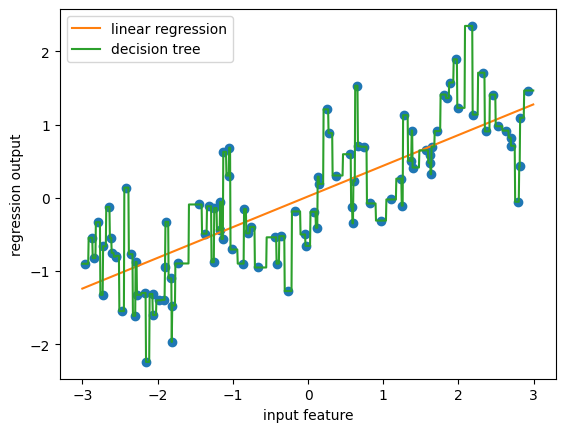

In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
import numpy as np

import mglearn
from mglearn.datasets import make_wave

X, y = mglearn.datasets.make_wave(n_samples=100)
plt.plot(X[:, 0], y, "o")
line = np.linspace(-3, 3, 1000)[:-1].reshape(-1, 1)

reg = LinearRegression().fit(X, y)
plt.plot(line, reg.predict(line), label="linear regression")

reg = DecisionTreeRegressor().fit(X, y)
plt.plot(line, reg.predict(line), label="decision tree")
plt.ylabel("regression output")
plt.xlabel("input feature")
plt.legend(loc="best")


### Interpretation

- **LinearRegression** fits one global line.
- **DecisionTreeRegressor** partitions the x-axis into intervals and predicts a constant value inside each interval.

So even with only one predictor, a tree can model a nonlinear relationship.



## 3. Binning a continuous variable

One way to make linear models more powerful on continuous data is to use **binning** (also called **discretization**).

The idea is:

1. split the continuous feature into intervals (bins)
2. assign each observation to a bin
3. one-hot encode the bin membership
4. fit a linear model on these binary features


In [2]:
np.set_printoptions(precision=2)
bins = np.linspace(-3, 3, 11)
which_bin = np.digitize(X, bins=bins)
print("\nData points:\n", X[:5])
print("\nBin membership for data points:\n", which_bin[:5])


Data points:
 [[-0.75]
 [ 2.7 ]
 [ 1.39]
 [ 0.59]
 [-2.06]]

Bin membership for data points:
 [[ 4]
 [10]
 [ 8]
 [ 6]
 [ 2]]



`np.digitize()` assigns each x-value to a bin index.

So conceptually:

- continuous feature → bin number

This is similar to turning a variable like `age` into age groups such as:

- child
- young adult
- middle-aged
- older adult


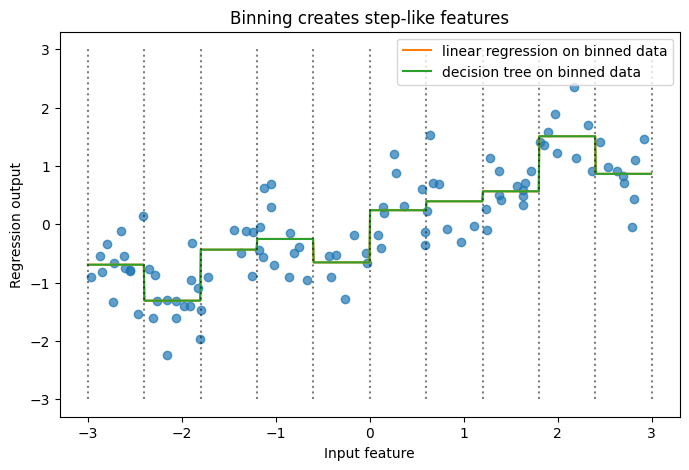

In [3]:

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoder.fit(which_bin)

X_binned = encoder.transform(which_bin)

# Important:
# line contains a dense sequence of x-values for plotting.
# We also need to assign these x-values to bins and encode them in the same way.
line_binned = encoder.transform(np.digitize(line, bins=bins))

plt.figure(figsize=(8, 5))
plt.plot(X[:, 0], y, "o", alpha=0.7)

reg = LinearRegression().fit(X_binned, y)
plt.plot(line, reg.predict(line_binned), label="linear regression on binned data")

reg = DecisionTreeRegressor(min_samples_split=3, random_state=0).fit(X_binned, y)
plt.plot(line, reg.predict(line_binned), label="decision tree on binned data")

for b in bins:
    plt.plot([b, b], [-3, 3], ":", c="k", alpha=0.5)

plt.ylabel("Regression output")
plt.xlabel("Input feature")
plt.title("Binning creates step-like features")
plt.legend(loc="best")
plt.show()



### What is happening here?

There are **two separate steps**:

#### Step 1: `np.digitize`
This converts a continuous value into a **bin index**.

Example:

- `x = -2.1` → bin 1
- `x = 0.3` → bin 5
- `x = 2.4` → bin 9

#### Step 2: `OneHotEncoder`
This converts the bin index into a **set of binary indicator variables**.

Example:

- bin 5 → `[0, 0, 0, 0, 1, 0, 0, 0, 0, 0]`

So the overall pipeline is:

**continuous feature → discretization → one-hot encoding → regression**

This allows a linear model to fit a **piecewise constant** function.



## 4. Connection to broader methods intuition

It is useful to view one-hot encoding as a **design-matrix transformation**.

In that sense:

- `pd.get_dummies()` creates indicator columns for categories
- `OneHotEncoder()` does the same in scikit-learn
- `np.digitize()` first turns a continuous variable into categorical bin labels

So mathematically, these methods are all about changing the **representation** of the input variable.



## Key takeaways

- `pd.get_dummies()` and `OneHotEncoder()` have the same basic goal: **convert categories into binary columns**
- `np.digitize()` performs **binning / discretization** of a continuous variable
- Binning + one-hot encoding can make a linear model behave more flexibly
- This is one example of **feature engineering**: changing the representation of the data so the model can capture structure more effectively
